# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
#IMPORTS PRINCIPALES:
import pandas  as pd               # LECTURA, MANEJO Y TRANSFORMACIÓN DE DATAFRAMES.
import numpy   as np               # FUNCIONES MATEMÁTICAS RELEVANTES.
import matplotlib.pyplot as plt    # GRÁFICOS.
import seaborn as sns              # GRÁFICOS PRETTY.
from scipy.stats import ttest_ind  # Promedios (2 Grupos)
from scipy.stats import levene     # Varianzas
from statsmodels.stats.proportion import proportions_ztest  # Proporciones% Binarios
from scipy.stats import chi2_contingency #Chi cuadrado (categórica)

#CONFIGURACIONES GLOBALES:
import warnings                                                #MANEJO DE WARNINGS - ADVERTENCIAS
warnings.simplefilter(action='ignore', category=FutureWarning) #QUITAR WARNINGS MOLESTOS
pd.set_option('display.max_columns', None)                     #ELIMINA LIMITES DE PANDAS PARA MOSTRAR COLUMNAS
pd.set_option('display.max_rows', None)                        #ELIMINA LIMITES DE PANDAS PARA MOSTRAR FILAS
pd.set_option('display.max_colwidth', None)


In [2]:
# cargar archivo
# df = pd.read_csv('/datasets/landing_experiment.csv')

In [3]:
# Cargar el dataset y explorar datos
path = 'https://raw.githubusercontent.com/FithoGerardo/ab_experiment_landing_page/refs/heads/main/data/landing_experiment.csv'
df = pd.read_csv(path)

In [4]:
# Guardar copia
# df.to_csv('landing_experiment.csv', index=False, encoding='utf-8')

In [5]:
# copia df
dfc = df.copy() #dfc = df_copy

**Vista previa e información general del conjunto de datos**

In [6]:
display(dfc.head(5))

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [7]:
display(dfc.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


None

**Detección y corrección de inválidos y sentinels**

In [8]:
display(dfc.columns)
col_num = ['gasto']
col_cat = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
col_bina = ['converted']
col_date = ['date']

Index(['user_id', 'date', 'landing', 'region', 'dispositivo', 'traffic_source',
       'user_type', 'converted', 'gasto'],
      dtype='object')

In [9]:
# Verificar usuarios únicos
print("Columna user_id")
unique_users_num = dfc['user_id'].nunique()
print("Usuarios únicos: ", unique_users_num)
print()

# Resumen estadístico
print(f"Columnas numéricas: {col_num}")
for col in col_num:
  display(dfc[col].describe())
  print()

# Verificar categorías esperadas del experimento ( A y B).
print(f"Columnas categóricas: {col_cat}")
for col in col_cat:
  print(f"Columna: {col}")
  display(dfc[col].describe())
  print()
  display(dfc[col].value_counts().reset_index())
  print()

print(f"Columnas binarias: {col_bina}")
for col in col_bina:
  display(dfc[col].describe())
  print("\nResumen estadístico de usuarios que se convirtieron\n")
  display(dfc[col].value_counts().reset_index())
  print()

print(f"Columnas de fecha: {col_date}")
for col in col_date:
  display(dfc[col].describe())
  print()

Columna user_id
Usuarios únicos:  40000

Columnas numéricas: ['gasto']


,gasto
count,40000.000000
mean,9.325554
std,25.667986
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,303.680000



Columnas categóricas: ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
Columna: landing


,landing
count,40000
unique,2
top,B
freq,20018


,landing,count
0,B,20018
1,A,19982


...

,converted
count,40000.00000
mean,0.14265
std,0.34972
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,1.00000



Resumen estadístico de usuarios que se convirtieron



,converted,count
0,0,34294
1,1,5706



Columnas de fecha: ['date']


,date
count,40000
unique,28
top,2026-01-24
freq,1512


**Comentarios:**
- El dataset NO tiene valores ausentes.

- Convertir columna 'date' (object) a (date).
- 40,000 user_id diferentes
- landing = {B:	20018, A:	19982}
- Gasto Min  Max = 0, 303.68
- 5 region diferentes Top Norte 11166
- - **Norte, Centro, Sur, Occidente, Oriente**
- 2 dispositivo Top Mobile 24829
- - **Mobile, Desktop**
- 4 traffic_source Top Organic 17987
- - **Organic, Ads, Email, Referral**
- user_type = {Nuevo: 26033, Recurrente: 13967}
- converted = {0: 34294, 1: 5706}
- date unique 28 top 2026-01-24 freq 1512

**Convertir columna 'date' (object) a (date).**

In [10]:
# Convertir 'date' a fecha
dfc['date'] = pd.to_datetime(dfc['date'], errors='coerce')
# Confirmando cambios
print(f"Columnas de fecha: {col_date}")
for col in col_date:
  display(dfc[col].describe())
  print()
  display(dfc['date'].info())
  print()

# Identificar rango temporal del experimento
print("Fecha mínima:", dfc["date"].min())
print("Fecha máxima:", dfc["date"].max())

Columnas de fecha: ['date']


,date
count,40000
mean,2026-01-14 11:41:06
min,2026-01-01 00:00:00
25%,2026-01-07 00:00:00
50%,2026-01-14 00:00:00
75%,2026-01-21 00:00:00
max,2026-01-28 00:00:00



<class 'pandas.core.series.Series'>
RangeIndex: 40000 entries, 0 to 39999
Series name: date
Non-Null Count  Dtype         
--------------  -----         
40000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 312.6 KB


None


Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


Columna 'date' abarca del día 1 - 28 de enero 2026

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


In [11]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Comentarios:**
- Todas las columnas tienen valores esperados.
- Se hicieron correcciones en el apartado anterior.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [31]:
# Agrupación A y B & Converted 1
dfc_A = dfc[(dfc['landing'] == 'A')]
dfc_B = dfc[(dfc['landing'] == 'B')]

conv_A = dfc_A[(dfc_A['converted'] == 1)]
conv_B = dfc_B[(dfc_B['converted'] == 1)]

# Gasto por versión (solo usuarios convertidos)
gasto_A = conv_A['gasto']
gasto_B = conv_B['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t de Student t-test

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio es igual en ambas páginas.
- **Hipótesis alternativa (H₁):** El gasto promedio es diferente entre las páginas.

In [37]:
print("="*50)
print("COMPARACIÓN DE GASTO: PÁGINA A vs PÁGINA B")
print("="*50)

print(f"\nPÁGINA A (landing='A', converted=1):")
print(f"   Cantidad de usuarios: {len(gasto_A)}")
print(f"   Gasto promedio: ${gasto_A.mean():.2f}")
print(f"   Desv. estándar: ${gasto_A.std():.2f}")
print(f"   Mediana: ${gasto_A.median():.2f}")
print(f"   Mín - Máx: ${gasto_A.min():.2f} - ${gasto_A.max():.2f}")

print(f"\nPÁGINA B (landing='B', converted=1):")
print(f"   Cantidad de usuarios: {len(gasto_B)}")
print(f"   Gasto promedio: ${gasto_B.mean():.2f}")
print(f"   Desv. estándar: ${gasto_B.std():.2f}")
print(f"   Mediana: ${gasto_B.median():.2f}")
print(f"   Mín - Máx: ${gasto_B.min():.2f} - ${gasto_B.max():.2f}")

# DIFERENCIA
diferencia = gasto_A.mean() - gasto_B.mean()
diferencia_pct = (diferencia / gasto_B.mean()) * 100
print(f"\nDIFERENCIA:")
print(f"   Valor: ${diferencia:.2f}")
print(f"   Porcentaje: {diferencia_pct:.2f}%")

# TEST T-STUDENT
t_statistic, p_value = ttest_ind(gasto_a, gasto_b)
print(f"\nTEST T-STUDENT:")
print(f"   Estadístico t: {t_statistic:.4f}")
print(f"   P-value: {p_value:.4e}")
if p_value < 0.05:
    print(f"Se rechaza hipótesis nula. Diferencia SIGNIFICATIVA al {1-p_value:.2%} aprox. de confianza")
else:
    print(f"NO se rechaza hipótesis nula. Diferencia NO significativa al 95% de confianza")

COMPARACIÓN DE GASTO: PÁGINA A vs PÁGINA B

PÁGINA A (landing='A', converted=1):
   Cantidad de usuarios: 2512
   Gasto promedio: $61.09
   Desv. estándar: $28.88
   Mediana: $55.84
   Mín - Máx: $12.12 - $303.68

PÁGINA B (landing='B', converted=1):
   Cantidad de usuarios: 3194
   Gasto promedio: $68.75
   Desv. estándar: $32.00
   Mediana: $62.57
   Mín - Máx: $12.98 - $249.99

DIFERENCIA:
   Valor: $-7.66
   Porcentaje: -11.14%

TEST T-STUDENT:
   Estadístico t: -9.3656
   P-value: 1.0635e-20
Se rechaza hipótesis nula. Diferencia SIGNIFICATIVA al 100.00% aprox. de confianza


### Conclusión e interpretación

**Decisión:**  
Se rechaza hipótesis nula. Diferencia SIGNIFICATIVA al 100.00%% aprox. de confianza.

**Interpretación de negocio:**

La Página B genera mayor valor económico que la Página A.

- Los usuarios que se convirtieron en la Página B gastaron en promedio \$68.75, mientras que en la Página A gastaron \$61.09.
- Esto representa una diferencia de \$7.66 (11.14% más alto) en la Página B.
- Con 3,194 usuarios convertidos en B vs 2,512 en A, el impacto económico acumulado es sustancial.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z - Test

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre las páginas.

In [46]:
# CALCULAR TASA DE CONVERSIÓN POR PÁGINA
print("="*60)
print("COMPARACIÓN DE TASA DE CONVERSIÓN: PÁGINA A vs PÁGINA B")
print("="*60)

"""
La columna conversión tiene únicamente 1s y 0s.
Al sumar toda la columna, se ignoran los 0s y es equivalente
a contar la cantidad de 1s que aparecen en la columna.
"""

# Número de exitos y número total de registros
conversiones  = dfc.groupby('landing')['converted'].sum()
totales       = dfc.groupby('landing')['converted'].count()

# Pasar los valores a formato lista
exitos        = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

z_statistic, p_value = proportions_ztest(conversiones, nobs=observaciones)

print("\nCantidad de conversiones por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

# [0] y [1]: Indican que los datos vienen de una lista o arreglo donde el índice
# 0 corresponde al Grupo A (Control) y el índice 1 al Grupo B (Tratamiento).

tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

# Usuarios convertidos
convertidos = (conv_B['converted'].sum() - conv_A['converted'].sum())

# Mejora Relativa
mejora_relativa = (tasa_B - tasa_A) / tasa_A

print(f"Tasa de conversión grupo A: {tasa_A:.2%}")
print(f"Tasa de conversión grupo B: {tasa_B:.2%}")
# DIFERENCIA

print(f"\nDiferencia de tasas: {(tasa_A - tasa_B):.2%}")
print(f"Usuarios convertidos: {convertidos}")
print(f"Mejora relativa: {mejora_relativa:.2%}")

if tasa_A > tasa_B:
    print(f"\nEl grupo A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nEl grupo B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%}).")
else:
    print("\nAmbas grupos tienen la misma tasa de conversión.")

print(f"\nTEST Z-TEST:")
print("Estadístico Z:", z_statistic)
print(f"Valor p: {p_value:.4e}")

# Umbral de significancia
if p_value < 0.05:
    print(f"Rechazamos la hipótesis nula: Diferencia SIGNIFICATIVA al {1-p_value:.2%} aprox. de confianza.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

COMPARACIÓN DE TASA DE CONVERSIÓN: PÁGINA A vs PÁGINA B

Cantidad de conversiones por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64
Tasa de conversión grupo A: 12.57%
Tasa de conversión grupo B: 15.96%

Diferencia de tasas: -3.38%
Usuarios convertidos: 682
Mejora relativa: 26.92%

El grupo B tiene una mayor tasa de conversión (3.38%).

TEST Z-TEST:
Estadístico Z: -9.677362674655983
Valor p: 3.7630e-22
Rechazamos la hipótesis nula: Diferencia SIGNIFICATIVA al 100.00% aprox. de confianza.


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: Diferencia SIGNIFICATIVA al 100.00% aprox. de confianza.

**Interpretación de negocio:**  
Con un p-value de 3.76e-22 (prácticamente cero), mucho menor que el nivel de significancia de 0.05, y un estadístico Z de -9.68, tenemos evidencia estadística extremadamente sólida de que existe una diferencia real en la tasa de conversión entre ambas páginas. Esta diferencia definitivamente no es por azar.

- Página A generó: 2,512 conversiones
- Página B generó: 3,194 conversiones
- Diferencia: +682 conversiones adicionales (26.92% más)

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi Cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las dos variables (son independientes).
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las dos variables (no son independientes).

In [60]:
print("="*50)
print("ANÁLISIS CHI CUADRADA: FUENTE DE TRÁFICO vs CONVERSIÓN")
print("="*50)

# Tabla de contingencia para prueba Chi^2
contingency_table = pd.crosstab(dfc['traffic_source'], dfc['converted'])
print(contingency_table)

# Tabla de contingencia normalizada
print("\nTabla de contingencia normalizada")
display(pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100)

# Aplicar Chi Cuadrada
chi2_contingency(contingency_table)
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nPrueba Chi-Cuadrado:")
print(f"Estadístico chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor P: {p_value:.4e}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns )
display(expected_df)

# Umbral de significancia
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

ANÁLISIS CHI CUADRADA: FUENTE DE TRÁFICO vs CONVERSIÓN
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Tabla de contingencia normalizada


converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163



Prueba Chi-Cuadrado:
Estadístico chi-cuadrado: 8.6621
Valor P: 3.4138e-02
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


converted,0,1
traffic_source,,
Ads,10232.47225,1702.52775
Email,5249.55405,873.44595
Organic,15421.15445,2565.84555
Referral,3390.81925,564.18075


Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

**Interpretación de negocio:**  
Con un p-value de 0.0341 (menor que 0.05), y un estadístico χ² de 8.6621 con 3 grados de libertad, tenemos evidencia estadística significativa de que SÍ existe una relación entre la fuente de tráfico y la conversión. Las variables NO son independientes.

La fuente de tráfico SÍ afecta significativamente la conversión:
- Email y Ads Mejor rendimiento (14.74% - 14.99%)
- Organic y Referral necesitan optimización (13.79% - 13.88%)


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Z - Test

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas tipos de usuarios.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre los tipos de usuario.

In [65]:
# CALCULAR RELACIÓN TIPO DE USUARIO Y CONVERSIÓN
print("="*60)
print("ANÁLISIS Z-TEST: TIPO DE USUARIO vs CONVERSIÓN")
print("="*60)

# Número de exitos y número total de registros
conversiones2  = dfc.groupby('user_type')['converted'].sum()
totales2       = dfc.groupby('user_type')['converted'].count()

# Pasar los valores a formato lista
exitos2        = [conversiones2['Nuevo'], conversiones2['Recurrente']]
observaciones2 = [totales2['Nuevo'], totales2['Recurrente']]

z_statistic, p_value = proportions_ztest(conversiones2, nobs=observaciones2)

print("\nCantidad de conversiones por tipo de usuario:\n", conversiones2)
print("\nTotal de usuarios por tipo de usuario:\n", totales2)

# [0] y [1]: Indican que los datos vienen de una lista o arreglo donde el índice
# 0 corresponde al Grupo A (Control) y el índice 1 al Grupo B (Tratamiento).

tasa_A2 = exitos2[0] / observaciones2[0]
tasa_B2 = exitos2[1] / observaciones2[1]

# Usuarios convertidos
convertidos = (conv_B['converted'].sum() - conv_A['converted'].sum())

# Mejora Relativa
mejora_relativa2 = (tasa_B2 - tasa_A2) / tasa_A2

# Tabla de contingencia normalizada
print("\nTabla de contingencia normalizada")
display(pd.crosstab(df['user_type'], df['converted'], normalize='index')*100)

print(f"\nTasa de conversión grupo A: {tasa_A2:.2%}")
print(f"Tasa de conversión grupo B: {tasa_B2:.2%}")
# DIFERENCIA

print(f"\nDiferencia de tasas: {(tasa_A2 - tasa_B2):.2%}")
print(f"Usuarios convertidos: {convertidos}")
print(f"Mejora relativa: {mejora_relativa2:.2%}")

if tasa_A2 > tasa_B2:
    print(f"\nEl grupo A tiene una mayor tasa de conversión ({tasa_A2 - tasa_B2:.2%}).")
elif tasa_B2 > tasa_A2:
    print(f"\nEl grupo B tiene una mayor tasa de conversión ({tasa_B2 - tasa_A2:.2%}).")
else:
    print("\nAmbas grupos tienen la misma tasa de conversión.")

print(f"\nTEST Z-TEST:")
print("Estadístico Z:", z_statistic)
print(f"Valor p: {p_value:.4e}")

# Umbral de significancia
if p_value < 0.05:
    print(f"Rechazamos la hipótesis nula: Diferencia SIGNIFICATIVA al {1-p_value:.2%} aprox. de confianza.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

ANÁLISIS Z-TEST: TIPO DE USUARIO vs CONVERSIÓN

Cantidad de conversiones por tipo de usuario:
 user_type
Nuevo         3738
Recurrente    1968
Name: converted, dtype: int64

Total de usuarios por tipo de usuario:
 user_type
Nuevo         26033
Recurrente    13967
Name: converted, dtype: int64

Tabla de contingencia normalizada


converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356



Tasa de conversión grupo A: 14.36%
Tasa de conversión grupo B: 14.09%

Diferencia de tasas: 0.27%
Usuarios convertidos: 682
Mejora relativa: -1.87%

El grupo A tiene una mayor tasa de conversión (0.27%).

TEST Z-TEST:
Estadístico Z: 0.7315745009057923
Valor p: 4.6443e-01
No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.

**Interpretación de negocio:**  
Con un p-value de 0.4644 (mucho mayor que 0.05), y un estadístico Z de 0.7316, no hay evidencia estadística significativa de que el tipo de usuario (Nuevo vs Recurrente) afecte la tasa de conversión. Las variables son prácticamente independientes.

- Recomendación: No segmentar por tipo de usuario; investigar por qué Recurrentes no convierten mejor

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

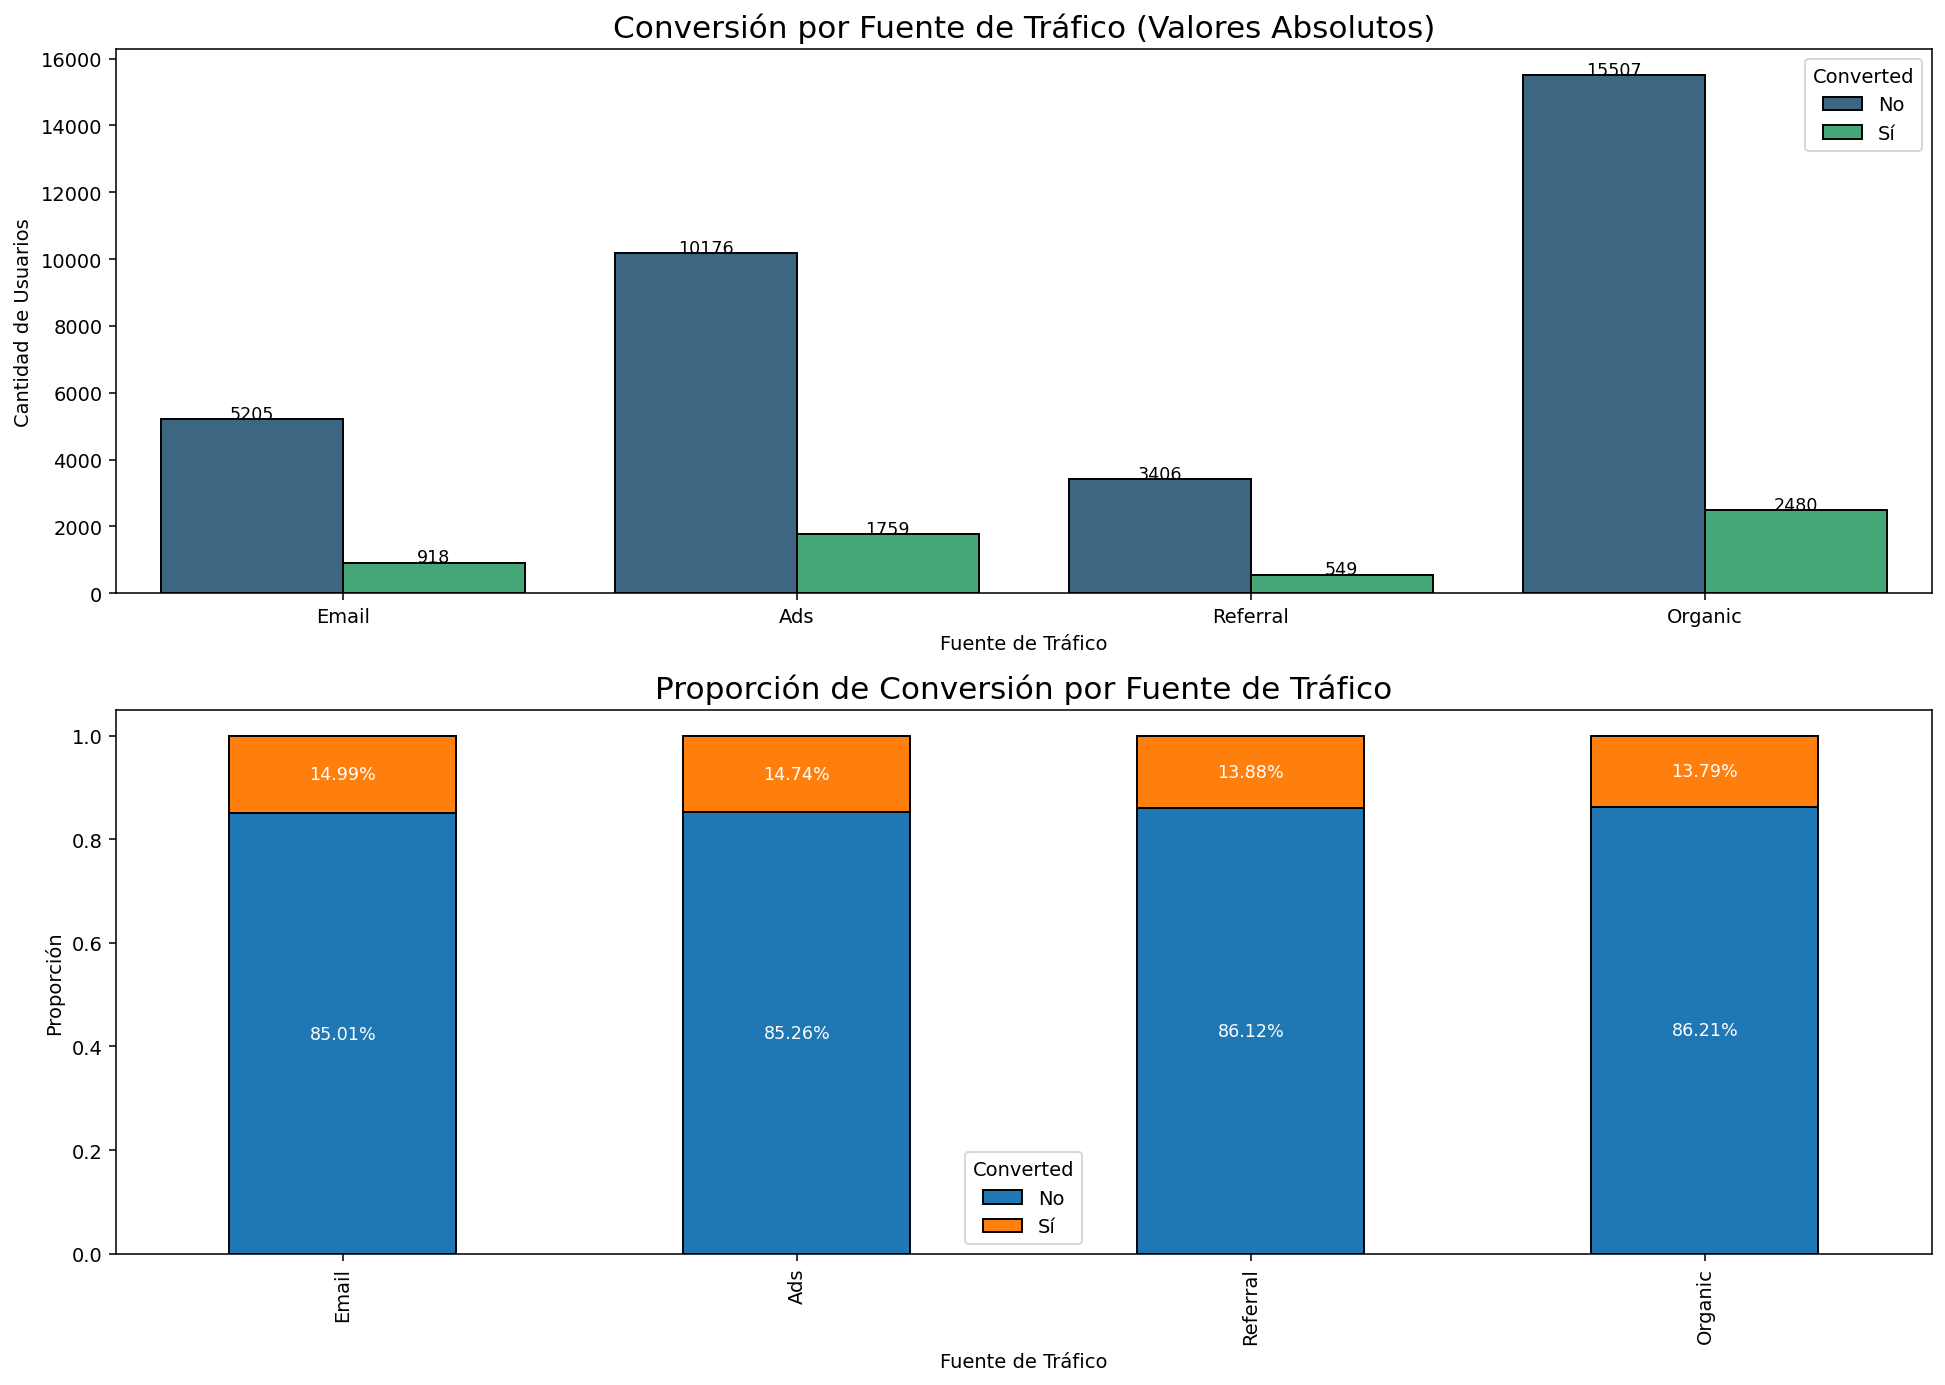

In [70]:
orden = ['Email', 'Ads', 'Referral', 'Organic']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=140)

# --- Gráfico 1: Valores absolutos ---
sns.countplot(
    x='traffic_source',
    data=dfc,
    hue='converted',
    order=orden,
    palette='viridis',
    edgecolor='black'
)

axes[0].set_title('Conversión por Fuente de Tráfico (Valores Absolutos)', fontsize=16)
axes[0].set_xlabel('Fuente de Tráfico')
axes[0].set_ylabel('Cantidad de Usuarios')
axes[0].legend(title='Converted', labels=['No', 'Sí'])

# etiquetas
for bar in axes[0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            height + 10,
            f'{int(height)}',
            ha='center',
            fontsize=9
        )

# --- Gráfico 2: proporciones ---
tabla_pct = pd.crosstab(dfc['traffic_source'], dfc['converted'], normalize='index')

# reordenar filas
tabla_pct = tabla_pct.reindex(orden)

tabla_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    edgecolor='black'
)

axes[1].set_title('Proporción de Conversión por Fuente de Tráfico', fontsize=16)
axes[1].set_xlabel('Fuente de Tráfico')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Converted', labels=['No', 'Sí'])

# etiquetas %
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        axes[1].text(
            x + width/2,
            y + height/2,
            f'{height:.2%}',
            ha='center',
            va='center',
            color='white',
            fontsize=9
        )

plt.tight_layout()
plt.savefig('conversion_proporcion_x_trafico.png')
plt.show()

El gráfico muestra la conversión segmentada por fuente de tráfico desde dos enfoques:

- Arriba (valores absolutos): volumen total de usuarios que convierten vs. no convierten por canal.
- Abajo (proporciones): tasa de conversión relativa dentro de cada fuente.

Se observa que Organic domina en volumen, seguido por Ads, Email y Referral. Sin embargo, al normalizar, las diferencias reales aparecen en las tasas de conversión, no en el volumen.

**Conclusiones y hallazgos**

1. Diferencias reales pero sutiles en conversión
- Email (\~14.99%) y Ads (\~14.74%) tienen mejor tasa.
- Organic (\~13.79%) y Referral (\~13.88%) quedan por debajo.
- La brecha es pequeña (\~1 pp), pero consistente.
2. Volumen vs. eficiencia
- Organic genera más conversiones absolutas (2480) porque tiene más tráfico, no porque sea más eficiente.
- Email, con menor volumen, es el canal más eficiente.
3. Resultado estadístico (Chi-cuadrado)
- p-value = 0.034 < 0.05
- Se rechaza independencia → la fuente de tráfico influye en la conversión
- Hallazgo estadísticamente significativo, aunque con efecto moderado.

**Conclusión ejecutiva**

La fuente de tráfico sí impacta la conversión. Aunque las diferencias no son drásticas, son estadísticamente significativas y accionables:

- Escalar Email y Ads
- Optimizar Organic
- Reevaluar Referral

---

### Relación entre el tipo de usuario y la conversión

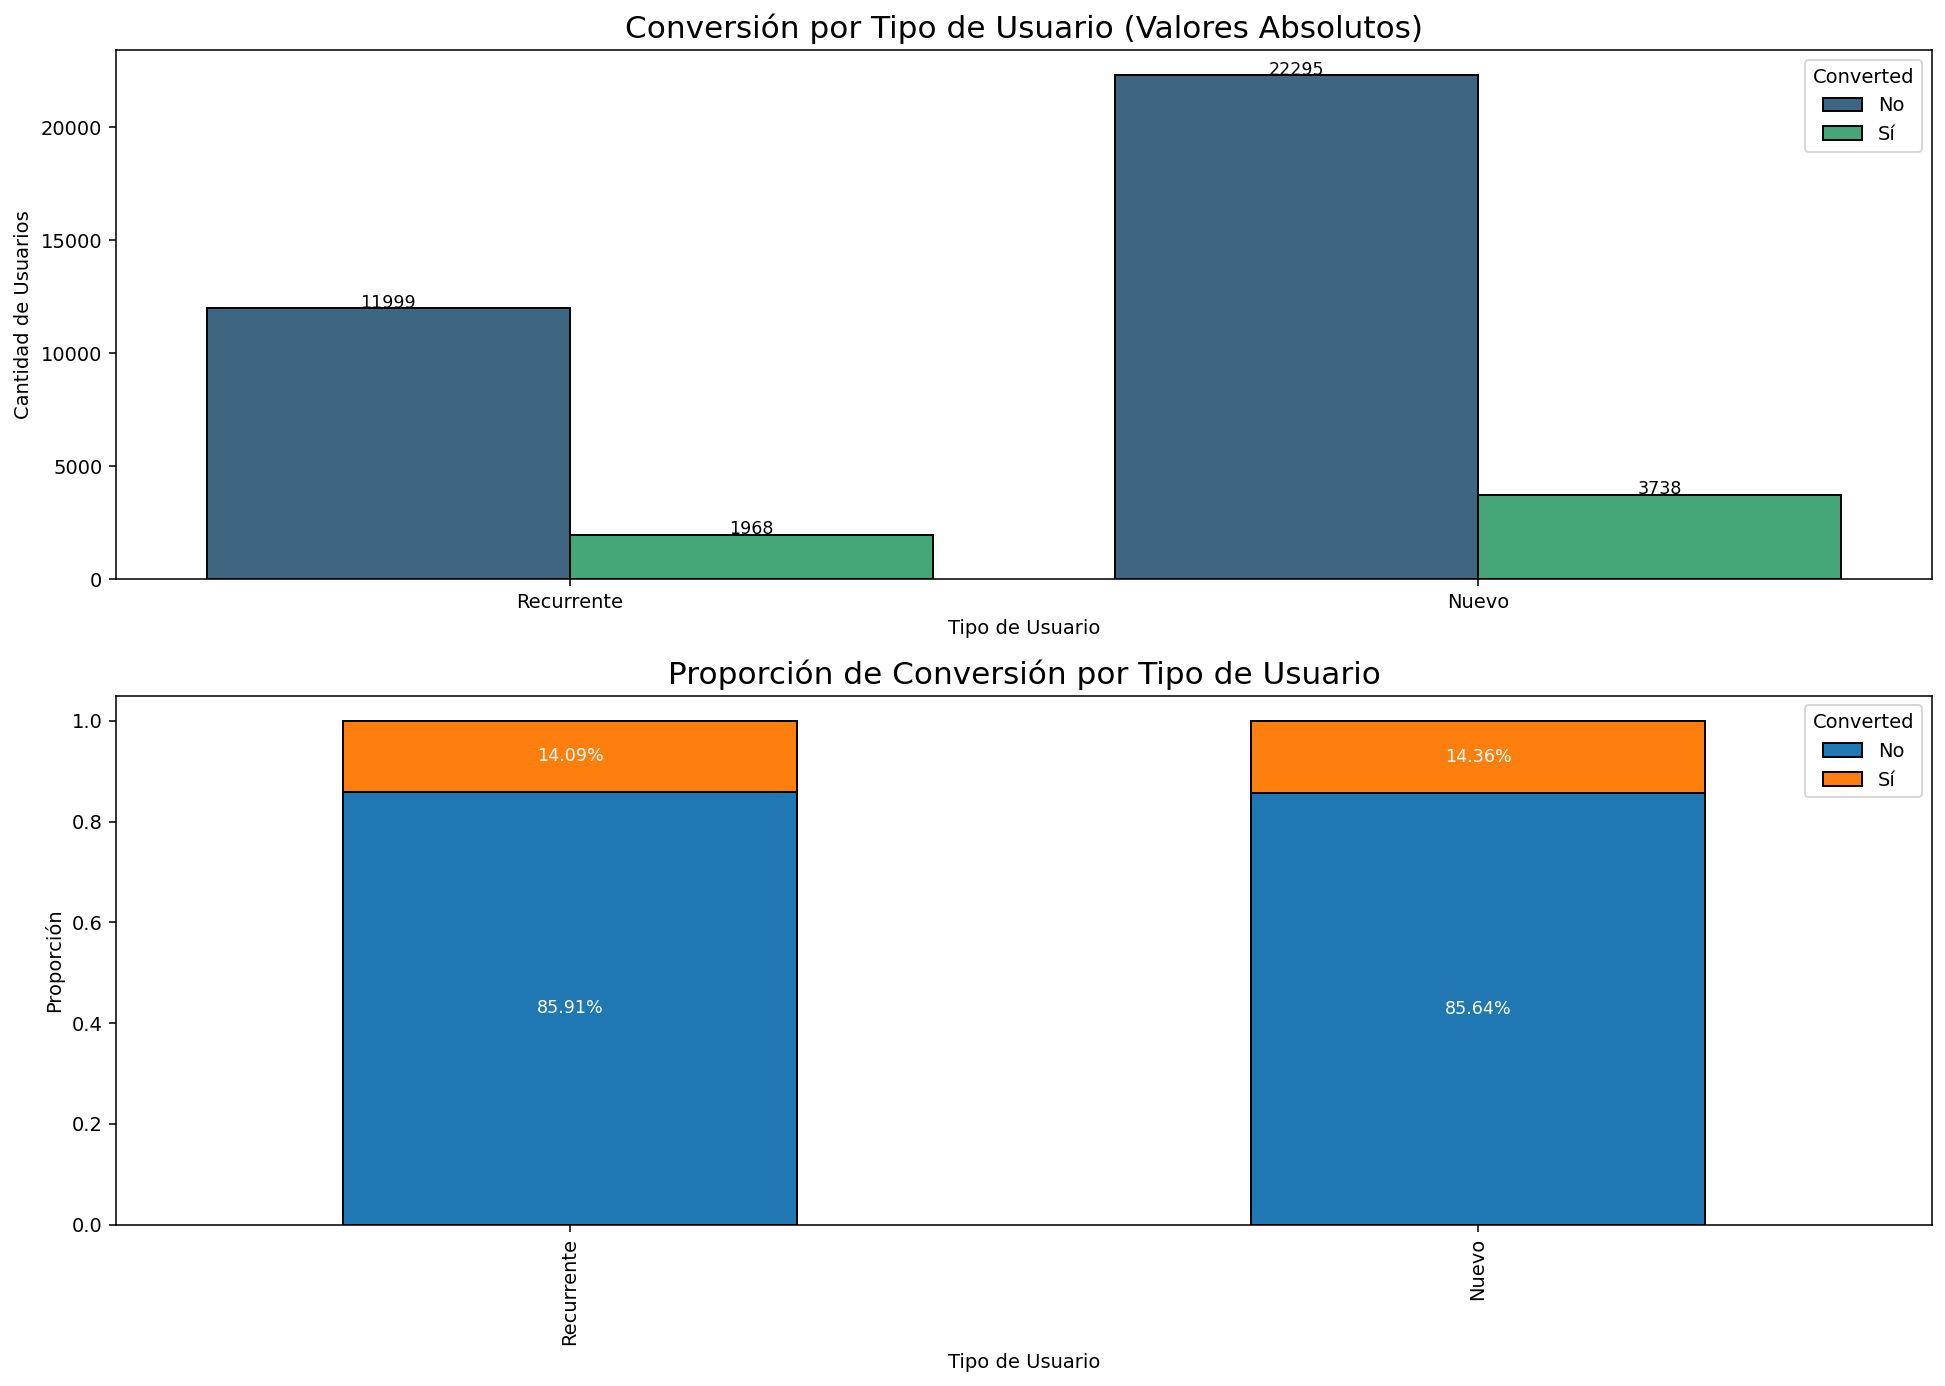

In [74]:
orden2 = ['Recurrente', 'Nuevo']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=140)

# --- Gráfico 1: Valores absolutos ---
sns.countplot(
    x='user_type',
    data=dfc,
    hue='converted',
    order=orden2,
    ax=axes[0],
    palette='viridis',
    edgecolor='black'
)

axes[0].set_title('Conversión por Tipo de Usuario (Valores Absolutos)', fontsize=16)
axes[0].set_xlabel('Tipo de Usuario')
axes[0].set_ylabel('Cantidad de Usuarios')
axes[0].legend(title='Converted', labels=['No', 'Sí'])

# etiquetas
for bar in axes[0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            height + 10,
            f'{int(height)}',
            ha='center',
            fontsize=9
        )

# --- Gráfico 2: proporciones ---
tabla_pct = pd.crosstab(dfc['user_type'], dfc['converted'], normalize='index')

# reordenar filas
tabla_pct = tabla_pct.reindex(orden2)

tabla_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    edgecolor='black'
)

axes[1].set_title('Proporción de Conversión por Tipo de Usuario', fontsize=16)
axes[1].set_xlabel('Tipo de Usuario')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Converted', labels=['No', 'Sí'])

# etiquetas %
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        axes[1].text(
            x + width/2,
            y + height/2,
            f'{height:.2%}',
            ha='center',
            va='center',
            color='white',
            fontsize=9
        )

plt.tight_layout()
plt.savefig('conversion_proporcion_x_tipo_usuario.png')
plt.show()

El gráfico compara la conversión entre usuarios Nuevos vs. Recurrentes:

- Arriba (valores absolutos): mayor volumen en usuarios nuevos (más tráfico total).
- Abajo (proporciones): tasas de conversión prácticamente iguales entre ambos grupos (\~14%).

Se observa que Organic domina en volumen, seguido por Ads, Email y Referral. Sin embargo, al normalizar, las diferencias reales aparecen en las tasas de conversión, no en el volumen.

**Conclusiones y hallazgos**

1. Tasas de conversión casi idénticas
- Nuevo: 14.36%
- Recurrente: 14.09%
- Diferencia: +0.27 pp (marginal)
2. El volumen no implica mejor desempeño
- Los usuarios nuevos generan más conversiones absolutas (3738) solo porque son más.
- No son más eficientes que los recurrentes.
3. Resultado estadístico (Z-test)
- p-value = 0.4644 >> 0.05
- No hay diferencia estadísticamente significativa
- El tipo de usuario y la conversión son prácticamente independientes
4. Insight clave
- Contra la intuición, los usuarios recurrentes no convierten mejor que los nuevos.

**Conclusión ejecutiva**

El tipo de usuario no es un driver relevante de conversión en este experimento.
Las decisiones de optimización deben enfocarse en variables con impacto comprobado, no en esta segmentación.

---

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### Insight Ejecutivo basado en el Experimento A/B

#### **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La página B presenta un gasto promedio significativamente mayor: \$68.75 vs \$61.09 en la página A (+11.14%).
- Además, la página B tiene más usuarios convertidos (3194 vs 2512), amplificando el impacto económico total.

**Interpretación:**
- La página B no solo convierte más, sino que monetiza mejor cada conversión, generando mayor revenue por usuario.

<br>

**Tasa de conversión:**
- La página B tiene una tasa de conversión de 15.96% vs 12.57% en A (+3.38 pp).
- Esto representa +682 conversiones adicionales (+26.92%), con significancia estadística extremadamente alta (p ≈ 0).

**Interpretación:**
- La página B es claramente superior en performance: más eficiente en convertir tráfico y generar ingresos.

---

#### **Segmentación por fuente de tráfico**
- Email (\~14.99%) y Ads (\~14.74%) muestran mejores tasas de conversión que Organic (\~13.79%) y Referral (\~13.88%).
El test Chi-cuadrado confirma que esta diferencia es estadísticamente significativa (p = 0.034).

**Interpretación:**

La fuente de tráfico sí influye en la conversión.
- Canales más eficientes: Email, Ads
- Canales con oportunidad: Organic, Referral

 ---

#### **Segmentación por tipo de usuario**
- Las tasas de conversión son prácticamente iguales:

- Nuevo: 14.36%
- Recurrente: 14.09%
- Diferencia mínima (0.27 pp) y no significativa (p = 0.464).

**Interpretación:**
- El tipo de usuario no impacta la conversión. No hay evidencia para segmentar estrategia en base a esta variable.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### **Recomendaciones de negocio:**
1. Implementar la página B como versión definitiva.
- Maximiza tanto conversión como ingreso por usuario. Impacto directo en revenue.

2. Reasignar inversión hacia canales de mayor performance (Email y Ads).
- Optimizar presupuesto hacia fuentes con mayor eficiencia comprobada.

3. Optimizar canales de alto volumen pero menor conversión (Organic).
- Aplicar mejoras en UX, contenido o targeting para capturar su potencial.

4. Evitar segmentación por tipo de usuario en estrategias de conversión.
- No aporta valor. Enfocar esfuerzos en variables con impacto real.

5. Profundizar análisis en comportamiento post-click.
- Especialmente en Organic y Recurrentes, donde el desempeño es menor al esperado.

---

### **Conclusión ejecutiva**

El experimento demuestra que la página B es superior en todos los KPIs clave (conversión y revenue).

El mayor impacto en resultados proviene de:

- La versión de la página (factor principal)
- La fuente de tráfico (factor secundario pero significativo)

Mientras que el tipo de usuario no es un driver relevante.

La estrategia óptima es clara: escalar página B + optimizar mix de tráfico.